# **Workshop -001: Extract**

**Importación de las librerias a utilizar**

In [1]:
import yaml
import psycopg2 
from psycopg2 import sql
from sqlalchemy import create_engine, text
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from datetime import datetime

**Creamos una función donde leemos el archivo de configuración de la DB y cargamos los datos de la conexión**

In [3]:
def load_config(file_path="../../config/config.yaml"):
    with open(file_path, "r") as file:
        return yaml.safe_load(file)

**Llamamos a la funcion que carga los dados de conexión a la base de datos, y creamo la conexión**

In [4]:
config = load_config()
db_config = config["database"]

db_user = db_config["user"]
db_password = db_config["password"]
db_host = db_config["host"]
db_port = db_config["port"]
db_name = db_config["name"]

conn = psycopg2.connect(
    dbname="postgres",
    user=db_user,
    password=db_password,
    host=db_host,
    port=db_port
)
conn.autocommit = True

**Consultamos los datos de la tabla de *saldos_staging* para realizar el proceso de transformación**

In [6]:
engine = create_engine(f"postgresql://{db_user}:{db_password}@{db_host}:{db_port}/{db_name}")

with engine.connect() as conn:
    db_staging_df = pd.read_sql("SELECT * FROM saldos_staging", conn)
    
db_staging_df.sample(n=15)

,id,documento_identidad,nombre,apellido,sexo,estado_civil,fecha_ingreso,tipo_salario,salario,estrato,...,cuopen,valor_pagado,fecha_pago,mora_causado,mora_abono,mora_saldo,descripcion,codahor,debcre,fecha_registro
120148,296774,94522866,JORGE WILMER,LOPEZ RUIZ,M,4,2005-06-07,4,3927000.0,0,...,4.0,442747.0,31/07/2023,442747.0,442747.0,0.0,PTMO CONSUMO,4,D,2025-03-13 07:42:15.576935
87028,263654,31478328,CLAUDIA MILENA,MENESES MENESES,F,1,2017-03-23,4,1677500.0,2,...,7.0,27781.0,31/05/2024,27781.0,27781.0,0.0,BON-SOL,3,D,2025-03-13 07:42:15.576935
84356,260982,31479650,NIDIA LORENA,VERA RAMOS,F,2,2019-01-19,4,4155177.0,0,...,3.0,2617.0,27/12/2024,2617.0,2617.0,0.0,SERVICIO EXEQUIAL,3,D,2025-03-13 07:42:15.576935
74553,251179,31467841,MARLENE,VALENCIA LLANOS,F,1,2011-12-02,4,3927000.0,0,...,4.0,NaN,None,4783.0,0.0,4783.0,SERVICIO EXEQUIAL,3,D,2025-03-13 07:42:15.576935
92359,268985,31482264,PAOLA ANDREA,EDEN VALENCIA,F,1,2013-04-03,4,2100000.0,0,...,0.0,NaN,None,NaN,NaN,NaN,REVALORIZACION,3,C,2025-03-13 07:42:15.576935
100951,277576,31926429,ANA MILENA,SUAREZ VERDUGO,F,1,2017-02-24,4,1677500.0,2,...,0.0,NaN,None,NaN,NaN,NaN,REVALORIZACION,3,C,2025-03-13 07:42:15.576935
95746,272371,31481491,SANDRA PATRICIA,VILLEGAS GONZALEZ,F,4,2016-03-11,4,3927000.0,0,...,0.0,79977.0,30/11/2024,78540.0,78540.0,0.0,A/PERM,2,C,2025-03-13 07:42:15.576935
2668,179294,6344278,MANUEL HERNAN,TULANDE PAZ,M,2,2010-07-07,2,3728586.0,0,...,0.0,NaN,None,NaN,NaN,NaN,REVALORIZACION,3,C,2025-03-13 07:42:15.576935
165074,341700,1118308804,CAROLINA,SAENZ CARVAJAL,F,4,2016-02-24,4,2262857.0,2,...,0.0,NaN,None,NaN,NaN,NaN,REVALORIZACION,3,C,2025-03-13 07:42:15.576935
88959,265585,31480548,LILIANA,BUITRAGO TRIVI O,F,4,2016-04-14,4,1300000.0,0,...,0.0,NaN,None,NaN,NaN,NaN,REVALORIZACION,3,C,2025-03-13 07:42:15.576935


***

## EDA

**Vamos a realizar el Análisis Exploratorio de Datos (EDA)**

**Resumen General**
Filas y columnas: El dataset contiene múltiples filas (transacciones).

Variables clave:

Identificación: documento_identidad, nombre, apellido.

Demográficas: sexo, estado_civil, fecha_ingreso.

Financieras: salario, vlrsolicitud, valorob, saldo, cuota, tasaint, mora_saldo, vlr_debito, vlr_credito.

Temporales: fecsolic, fecaprob, fecfact, fecdesc, fecha_pago.

Categóricas: codahor, clades, clacuo, tipo_salario, , periodd.

**Creamos funcion para el EDA**

In [7]:
def perform_eda(df):
    # ====================
    # 1. Análisis Inicial
    # ====================
    print("="*50)
    print("1. Vista inicial de los datos")
    print("="*50)
    
    # Primeras filas
    print("\nPrimeras 5 filas:")
    display(df.head())
    
    # Estructura del dataset
    print("\nDimensión del dataset:", df.shape)
    print("\nTipos de datos:")
    print(df.dtypes)
    
    # Resumen estadístico
    print("\nResumen estadístico numérico:")
    display(df.describe())
    
    # ====================
    # 2. Limpieza y preparación de datos
    # ====================
    print("\n" + "="*50)
    print("2. Limpieza y preparación de datos")
    print("="*50)
    
    # Convertir 'NULL' a valores NaN
    df.replace('NULL', np.nan, inplace=True)
    
    # Manejo de fechas
    date_cols = ['fecsolic', 'fecaprob', 'fecfact', 'fecdesc', 'fecultcau', 'fecultpago', 'fecvemto', 'fecha_pago']
    for col in date_cols:
        df[col] = pd.to_datetime(df[col], dayfirst=True, errors='coerce')
    
    # Ajustar valores de saldo y saldo_inicial según la columna debcre
    if 'debcre' in df.columns:
        print("\nAjustando valores de saldo y saldo_inicial según 'debcre'...")
        df.loc[df['debcre'] == 'C', ['saldo', 'saldo_inicial']] *= -1
    
    # Función para categorizar con valor por defecto "Sin definir"
    def categorize_column(column, mapping):
        return column.map(mapping).fillna("Sin definir")
    
    # Categorizar la columna 'sexo'
    if 'sexo' in df.columns:
        print("\nCategorizando la columna 'sexo'...")
        sexo_map = {
            'M': 'Masculino',
            'F': 'Femenino'
        }
        df['sexo'] = categorize_column(df['sexo'], sexo_map)
    
    # Categorizar la columna 'estado_civil'
    if 'estado_civil' in df.columns:
        print("\nCategorizando la columna 'estado_civil'...")
        estado_civil_map = {
            1: 'Soltero',
            2: 'Casado',
            3: 'Viudo',
            4: 'Union libre',
            5: 'Soltero',
            6: 'N/A',
            7: 'Divorciado'
        }
        df['estado_civil'] = categorize_column(df['estado_civil'], estado_civil_map)
    
    # Categorizar la columna 'codahor'
    if 'codahor' in df.columns:
        print("\nCategorizando la columna 'codahor'...")
        codahor_map = {
            1: 'Aportes',
            2: 'Ahorros',
            3: 'Servicios',
            4: 'Creditos',
            5: 'Tarjeta credito',
            6: 'CDAT',
            7: 'Interes Cdats'
        }
        df['codahor'] = categorize_column(df['codahor'], codahor_map)
    
    # Categorizar la columna 'clades'
    if 'clades' in df.columns:
        print("\nCategorizando la columna 'clades'...")
        clades_map = {
            0: 'N/A',
            1: 'Nomina',
            2: 'Caja'
        }
        df['clades'] = categorize_column(df['clades'], clades_map)
    
    # Categorizar la columna 'clacuo'
    if 'clacuo' in df.columns:
        print("\nCategorizando la columna 'clacuo'...")
        clacuo_map = {
            1: 'Fija',
            2: 'Variable'
        }
        df['clacuo'] = categorize_column(df['clacuo'], clacuo_map)
    
    # Categorizar la columna 'tipo_salario'
    if 'tipo_salario' in df.columns:
        print("\nCategorizando la columna 'tipo_salario'...")
        tipo_salario_map = {
            1: 'Integral',
            2: 'Ley 50',
            3: 'Ley anterior',
            4: 'Otro',
            5: 'Ley 1278',
            6: 'Ley 2277'
        }
        df['tipo_salario'] = categorize_column(df['tipo_salario'], tipo_salario_map)
    
    # Categorizar la columna 'periodd'
    if 'periodd' in df.columns:
        print("\nCategorizando la columna 'periodd'...")
        periodd_map = {
            1: 'Mensual',
            2: 'Quincenal',
            3: 'Decadal',
            4: 'Semanal'
        }
        df['periodd'] = categorize_column(df['periodd'], periodd_map)
    
    # Valores faltantes
    print("\nValores faltantes por columna:")
    missing = df.isna().sum().sort_values(ascending=False)
    display(missing[missing > 0])
    
    # ======================
    # 3. Análisis Univariado
    # ======================
    print("\n" + "="*50)
    print("3. Análisis Univariado")
    print("="*50)
    
    # Distribución de variables numéricas clave
    num_cols = ['salario', 'saldo', 'vlr_debito', 'vlr_credito', 'mora_saldo']  
    plt.figure(figsize=(15, 10))
    for i, col in enumerate(num_cols, 1):
        plt.subplot(3, 2, i)
        sns.histplot(df[col], kde=True, bins=30)
        plt.title(f'Distribución de {col}')
        plt.axvline(df[col].median(), color='r', linestyle='--')
    plt.tight_layout()
    plt.show()
    
    # Conteo de categorías principales
    cat_cols = ['descripcion', 'sexo', 'estado_civil', 'tipovehiculo']
    plt.figure(figsize=(15, 10))
    for i, col in enumerate(cat_cols, 1):
        plt.subplot(2, 2, i)
        df[col].value_counts().head(10).plot(kind='bar')
        plt.title(f'Conteo por {col}')
        plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
    
    # ======================
    # 4. Análisis Bivariado
    # ======================
    print("\n" + "="*50)
    print("4. Análisis Bivariado")
    print("="*50)
    
    # Correlación entre variables numéricas
    corr_matrix = df[num_cols].corr()
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
    plt.title('Matriz de Correlación')
    plt.show()
    
    # Relación saldo vs tiempo
    if 'periodo' in df.columns:
        plt.figure(figsize=(12, 6))
        df.groupby('periodo')['saldo'].mean().plot()  
        plt.title('Evolución del Saldo Promedio por Periodo')
        plt.ylabel('Saldo Promedio')
        plt.xlabel('Periodo')
        plt.xticks(rotation=45)
        plt.show()
    
    # ========================
    # 5. Análisis Multivariado
    # ========================
    print("\n" + "="*50)
    print("5. Análisis Multivariado")
    print("="*50)
    
    # Saldo por tipo de producto y género
    if 'descripcion' in df.columns and 'sexo' in df.columns:
        plt.figure(figsize=(15, 8))
        sns.boxplot(x='descripcion', y='saldo', hue='sexo', data=df)  
        plt.title('Distribución de Saldo por Tipo de Producto y Género')
        plt.xticks(rotation=90)
        plt.show()
    
    # ======================
    # 6. Anomalías y Outliers
    # ======================
    print("\n" + "="*50)
    print("6. Detección de Anomalías")
    print("="*50)
    
    # Identificación de outliers en saldos
    plt.figure(figsize=(10, 6))
    sns.boxplot(x=df['saldo'])  
    plt.title('Distribución de Saldos')
    plt.show()
    
    # Transacciones extremas
    print("\nTop 5 transacciones con mayor saldo negativo:")
    display(df.nsmallest(5, 'saldo')[['documento_identidad', 'descripcion', 'saldo']])  
    
    # ======================
    # 7. Análisis Temporal
    # ======================
    if 'fecsolic' in df.columns:
        print("\n" + "="*50)
        print("7. Análisis Temporal")
        print("="*50)
        
        # Evolución temporal de solicitudes
        df['año'] = df['fecsolic'].dt.year
        plt.figure(figsize=(12, 6))
        df['año'].value_counts().sort_index().plot(kind='bar')
        plt.title('Cantidad de Transacciones por Año')
        plt.xlabel('Año')
        plt.ylabel('Cantidad')
        plt.show()

    # ======================
    # 8. Resumen Final
    # ======================
    print("\n" + "="*50)
    print("8. Resumen de Hallazgos")
    print("="*50)
    
    print(f"""Principales hallazgos:
    1. Distribución de salarios: {df['salario'].unique()}
    2. Variables con mayor correlación: {corr_matrix.unstack().sort_values(ascending=False).index[1]}
    3. Categoría más común: {df['descripcion'].mode()[0]}
    4. Porcentaje de valores faltantes: {(df.isna().mean().max()*100):.2f}%
    5. Rango temporal: {df['fecsolic'].min()} a {df['fecsolic'].max()}""")



1. Vista inicial de los datos

Primeras 5 filas:


,id,documento_identidad,nombre,apellido,sexo,estado_civil,fecha_ingreso,tipo_salario,salario,estrato,...,cuopen,valor_pagado,fecha_pago,mora_causado,mora_abono,mora_saldo,descripcion,codahor,debcre,fecha_registro
0,176626,294064,ISBEL,CHAMIZO HERNANDEZ,M,4,2003-12-12,4,2600000.0,0,...,0.0,52000.0,28/02/2023,52000.0,52000.0,0.0,APORTES,1,C,2025-03-13 07:42:15.576935
1,176627,294064,ISBEL,CHAMIZO HERNANDEZ,M,4,2003-12-12,4,2600000.0,0,...,0.0,52000.0,31/03/2023,52000.0,52000.0,0.0,APORTES,1,C,2025-03-13 07:42:15.576935
2,176628,294064,ISBEL,CHAMIZO HERNANDEZ,M,4,2003-12-12,4,2600000.0,0,...,0.0,52000.0,30/04/2023,52000.0,52000.0,0.0,APORTES,1,C,2025-03-13 07:42:15.576935
3,176629,294064,ISBEL,CHAMIZO HERNANDEZ,M,4,2003-12-12,4,2600000.0,0,...,0.0,52000.0,31/05/2023,52000.0,52000.0,0.0,APORTES,1,C,2025-03-13 07:42:15.576935
4,176630,294064,ISBEL,CHAMIZO HERNANDEZ,M,4,2003-12-12,4,2600000.0,0,...,0.0,52000.0,30/06/2023,52000.0,52000.0,0.0,APORTES,1,C,2025-03-13 07:42:15.576935



Dimensión del dataset: (176625, 45)

Tipos de datos:
id                              int64
documento_identidad            object
nombre                         object
apellido                       object
sexo                           object
estado_civil                    int64
fecha_ingreso                  object
tipo_salario                    int64
salario                       float64
estrato                         int64
tipovehiculo                    int64
lincred                         int64
fecsolic                       object
fecaprob                       object
fecfact                        object
fecdesc                        object
fecultcau                      object
fecultpago                     object
fecvemto                       object
plazo                           int64
vlrsolicitud                  float64
valorob                       float64
saldot                        float64
cuota                         float64
tasaint                       floa

,id,estado_civil,tipo_salario,salario,estrato,tipovehiculo,lincred,plazo,vlrsolicitud,valorob,...,saldo,saldo_inicial,vlr_debito,vlr_credito,cuopen,valor_pagado,mora_causado,mora_abono,mora_saldo,fecha_registro
count,176625.000000,176625.000000,176625.000000,1.766250e+05,176625.000000,176625.000000,176625.000000,176625.000000,1.766250e+05,1.766250e+05,...,1.766250e+05,1.766250e+05,1.766250e+05,1.766250e+05,176487.000000,1.145740e+05,1.151120e+05,1.151120e+05,1.151120e+05,176625
mean,264938.000000,2.402531,3.713523,2.748163e+06,1.392391,0.001891,460.216351,50.543162,7.152604e+05,7.156184e+05,...,3.865366e+04,2.036933e+04,1.300993e+05,1.118150e+05,3.873543,1.838419e+05,1.066960e+05,7.573461e+04,3.096135e+04,2025-03-13 07:42:15.576935680
min,176626.000000,0.000000,1.000000,0.000000e+00,0.000000,0.000000,1.000000,0.000000,0.000000e+00,0.000000e+00,...,-7.538257e+08,-8.970000e+07,-2.062251e+07,0.000000e+00,0.000000,0.000000e+00,-6.620500e+05,0.000000e+00,-9.324100e+05,2025-03-13 07:42:15.576935
25%,220782.000000,1.000000,4.000000,1.677500e+06,0.000000,0.000000,6.000000,0.000000,0.000000e+00,0.000000e+00,...,-3.607700e+04,-2.960000e+04,0.000000e+00,0.000000e+00,0.000000,2.395000e+03,2.617000e+03,1.206000e+03,0.000000e+00,2025-03-13 07:42:15.576934912
50%,264938.000000,2.000000,4.000000,2.000000e+06,2.000000,0.000000,6.000000,0.000000,0.000000e+00,0.000000e+00,...,-6.050000e+02,-4.860000e+02,0.000000e+00,2.120000e+03,0.000000,2.350800e+04,2.566800e+04,1.154000e+04,0.000000e+00,2025-03-13 07:42:15.576934912
75%,309094.000000,4.000000,4.000000,3.600000e+06,2.000000,0.000000,1029.000000,11.000000,3.653100e+04,3.653100e+04,...,2.093100e+04,1.569500e+04,0.000000e+00,3.355000e+04,5.000000,4.986300e+04,5.970000e+04,4.450000e+04,0.000000e+00,2025-03-13 07:42:15.576934912
max,353250.000000,7.000000,4.000000,2.019662e+07,5.000000,1.000000,9999.000000,9999.000000,1.300000e+08,1.300000e+08,...,4.510224e+08,1.300000e+08,6.258485e+08,9.270595e+08,343.000000,9.270595e+08,4.625577e+07,2.941516e+07,4.625577e+07,2025-03-13 07:42:15.576935
std,50987.389985,1.397003,0.702397,1.854160e+06,1.222035,0.043445,520.515912,614.792044,4.460374e+06,4.460342e+06,...,5.801590e+06,4.012174e+06,5.632891e+06,6.136913e+06,11.017882,7.620367e+06,5.217054e+05,2.361013e+05,4.451233e+05,NaN



2. Limpieza y preparación de datos

Ajustando valores de saldo y saldo_inicial según 'debcre'...

Categorizando la columna 'sexo'...

Categorizando la columna 'estado_civil'...

Categorizando la columna 'codahor'...

Categorizando la columna 'clades'...

Categorizando la columna 'clacuo'...

Categorizando la columna 'tipo_salario'...

Categorizando la columna 'periodd'...

Valores faltantes por columna:


fecvemto        109145
valor_pagado     62051
fecha_pago       62051
mora_causado     61513
mora_abono       61513
mora_saldo       61513
fecultcau        42904
fecaprob         10408
cuopen             138
fecultpago          75
dtype: int64


3. Análisis Univariado


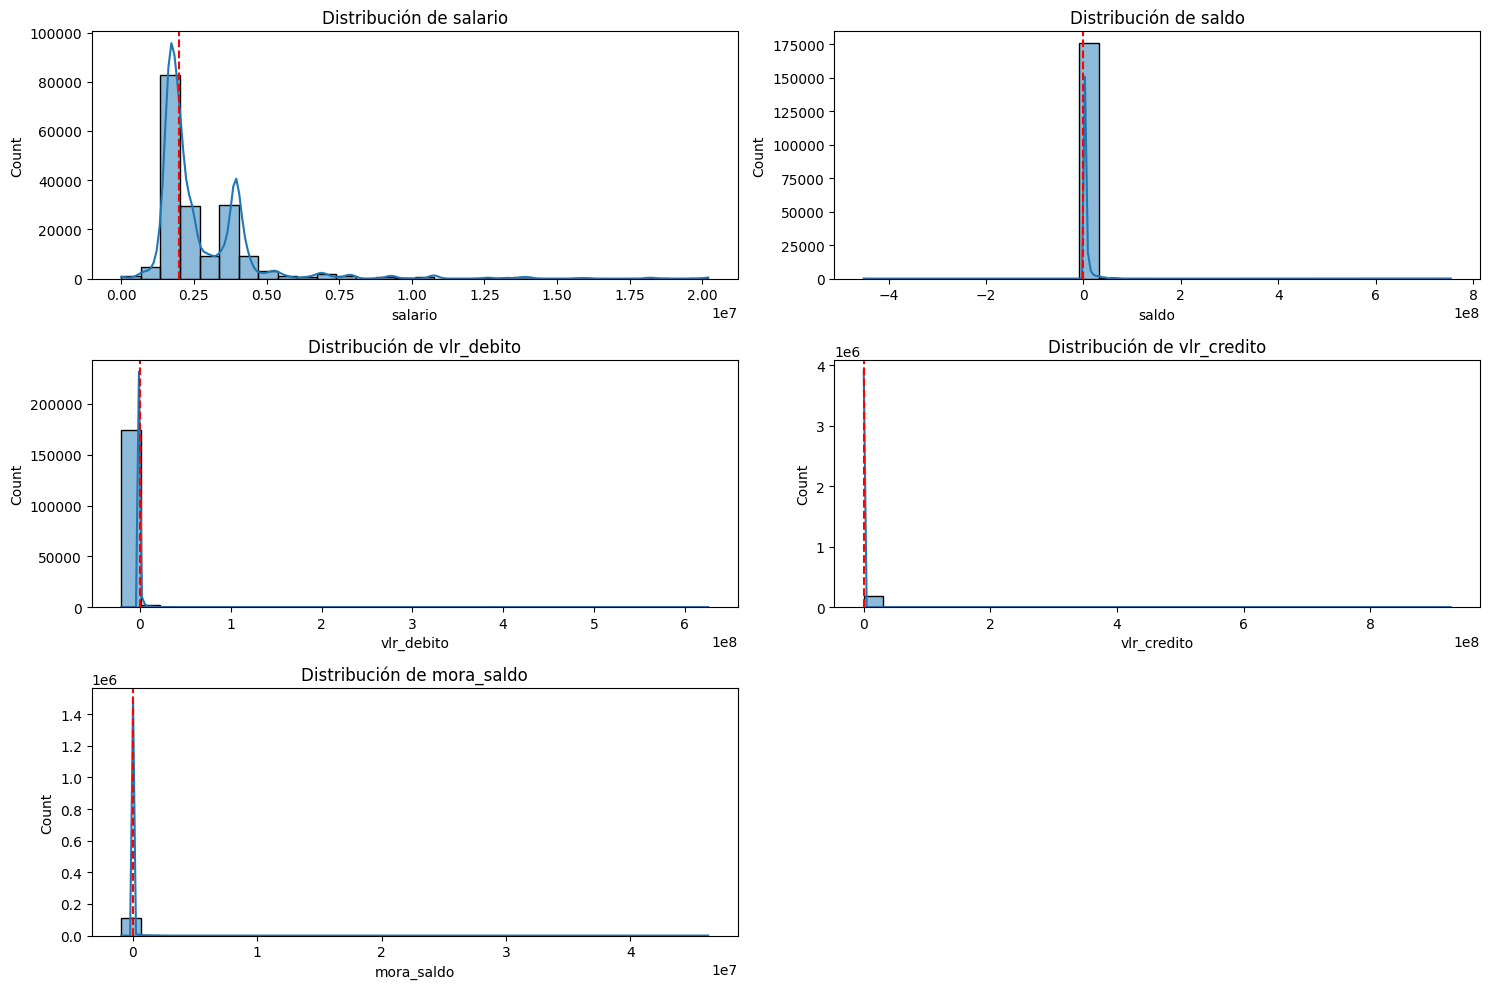

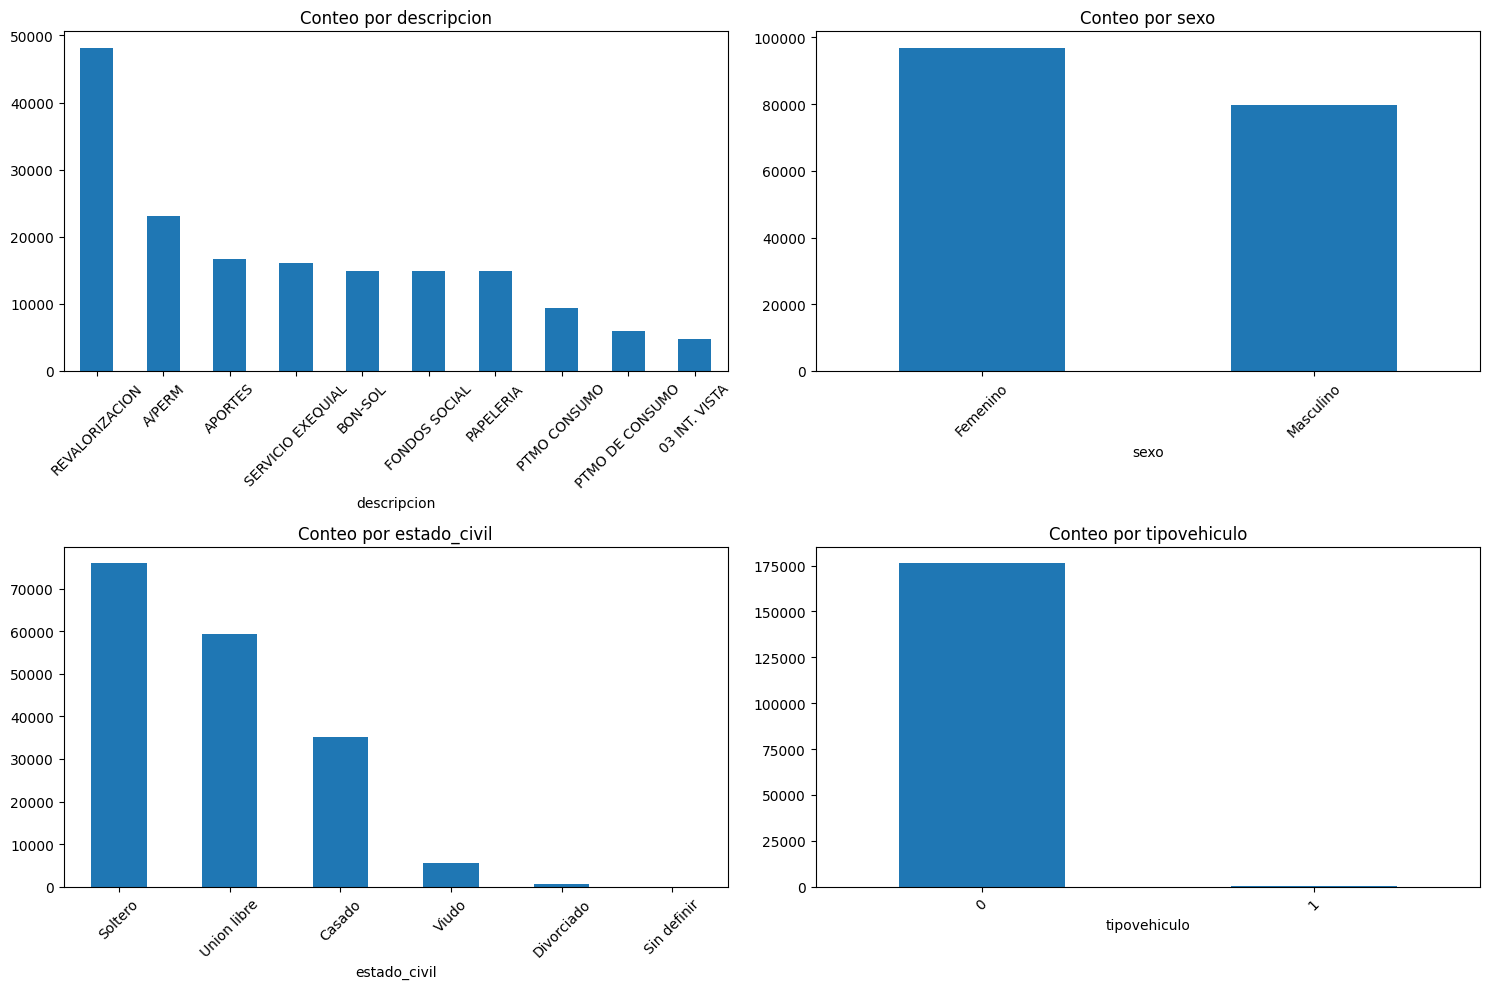


4. Análisis Bivariado


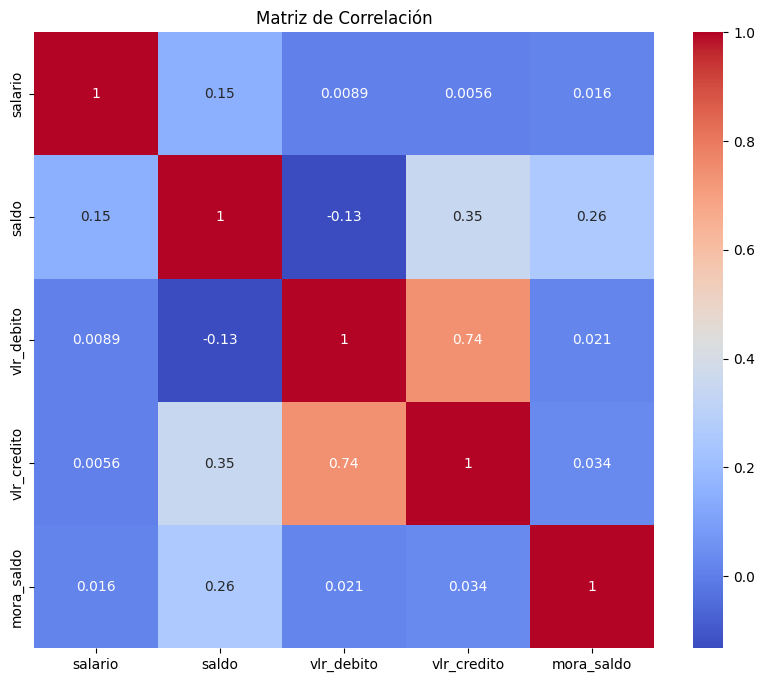

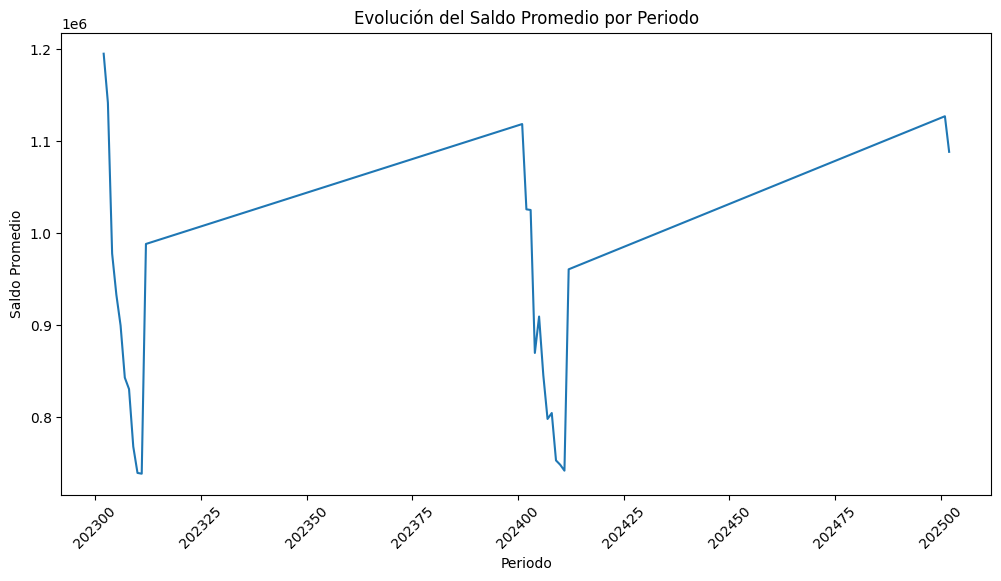


5. Análisis Multivariado


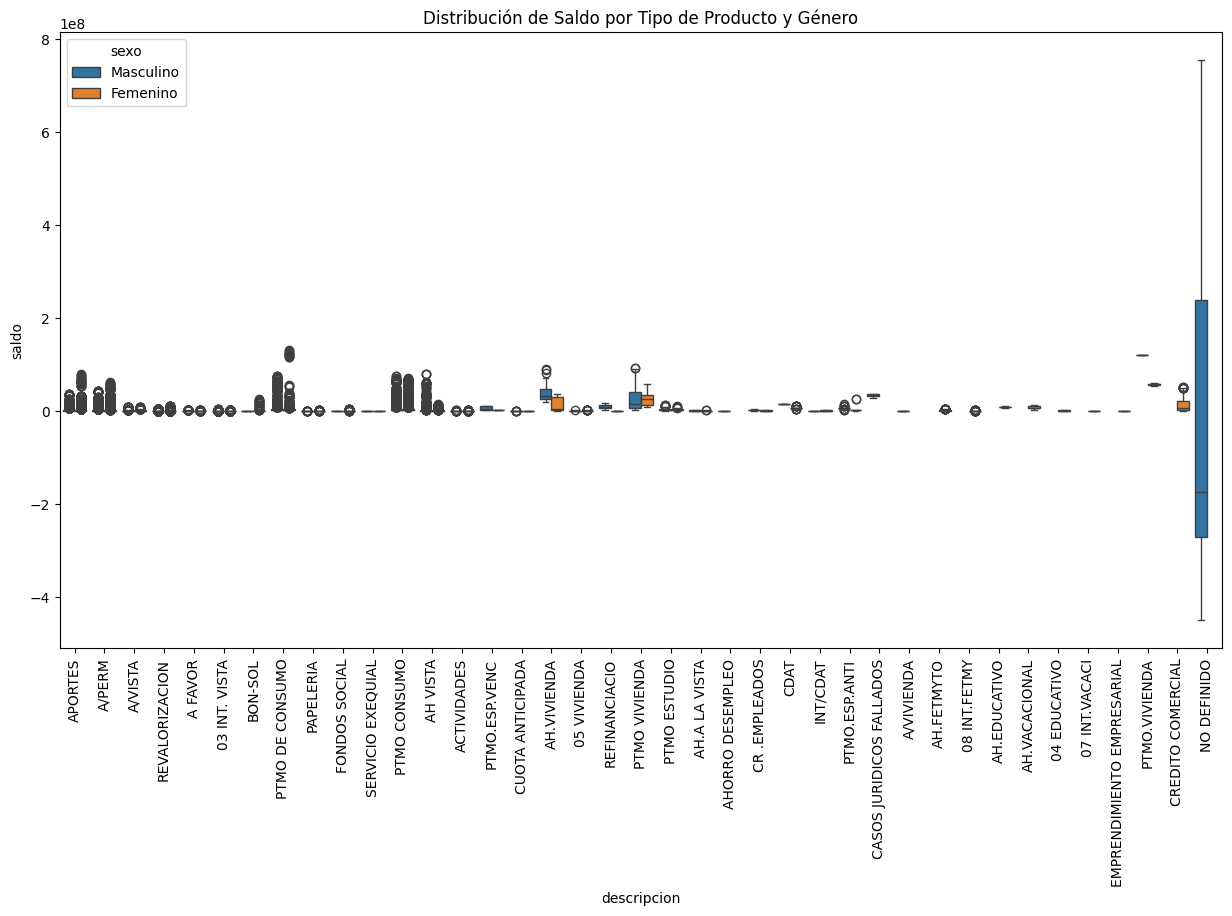


6. Detección de Anomalías


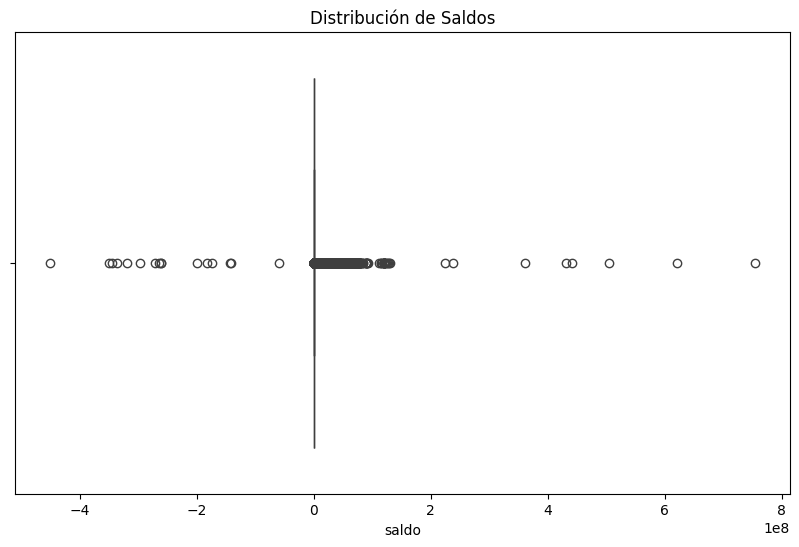


Top 5 transacciones con mayor saldo negativo:


,documento_identidad,descripcion,saldo
176619,99999999996618,NO DEFINIDO,-451022418.0
176620,99999999996618,NO DEFINIDO,-350275490.0
176617,99999999996618,NO DEFINIDO,-344943665.0
176605,99999999996618,NO DEFINIDO,-336019906.0
176622,99999999996618,NO DEFINIDO,-319286947.0



7. Análisis Temporal


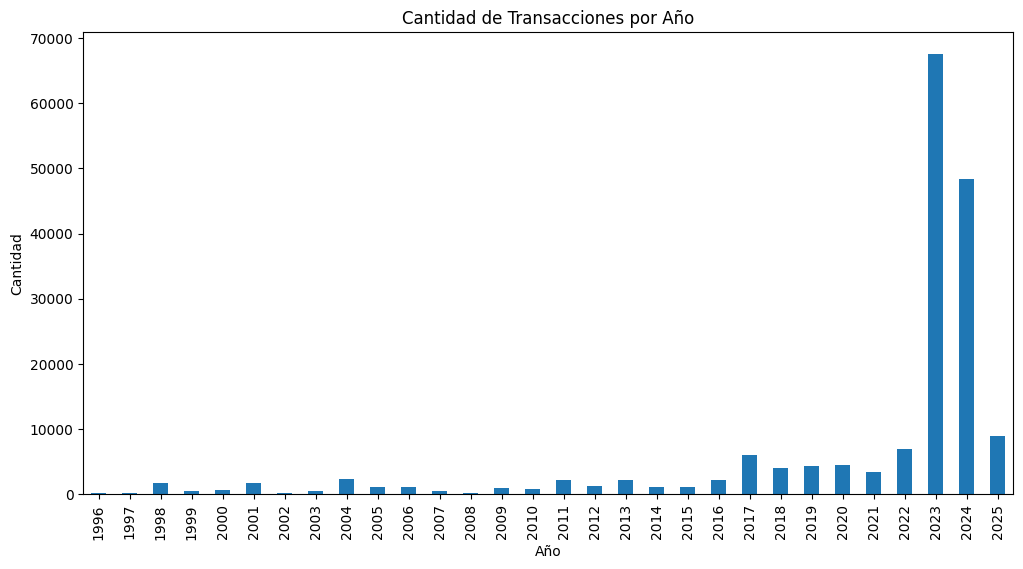


8. Resumen de Hallazgos
Principales hallazgos:
    1. Distribución de salarios: [ 2600000.  1900000.  2131432.  2284958.  1500000.  1677500.  2300000.
  4349959.  2798925.  1525000.  1844500.  1700000.  1980000.  2420000.
  1705000.  4251098.  4536000. 14092980.  4183334.  1800000.   774000.
  3728586.        0.  8816292.  8876282.  3041702.  3927000.  2106923.
  2200000.  4422207.  1272000.  1687513.  4001802.  1754000.  2000000.
  1626000.  1660000.  2100000.  2485856.  1863000.  3411360.  4255032.
  3762057.  4366892.  1450000.  1896063.  5964760.  3512000.  5203000.
  1522000.  1200000.  1680000.  6796805.  1740000.  1421000.  3800000.
  6628800.  4900000.   689454.  4284000.  1765732.  2615134.  3510324.
  3919989.  4154730.  1870000.  2566333.  3100000.  2769975.  2591073.
  1547700.  2856976.  2361517.  2722178.  1400000.  1300000.  1442000.
  3218000.  2077097.  2530000.  1482600.  2938344.  5743264.  1259775.
  1708670.  2666595.  1704000.   853426.  2094812. 10751862.  37803

In [8]:
# Ejecutar el EDA
perform_eda(db_staging_df)

***Hasta aqui segunda fase con la transformacion de la informacion***